### 1-Compréhension de la problématique

<b>Nous choisissons de traiter de traiter la prédiction des prix des billets d'avions</b>
<br><br>Sur le secteur aérien, les compagnies appliquent une tarification variable selon plusieurs facteurs à savoir : 
    <br>&nbsp;&nbsp;&nbsp;&nbsp;Principalement l'aéroport de départ et d'arrivé
    <br>&nbsp;&nbsp;&nbsp;&nbsp;L'heure du vol (départ et arrivée)
    <br>&nbsp;&nbsp;&nbsp;&nbsp;Nombre d'escale
    <br>&nbsp;&nbsp;&nbsp;&nbsp;La classe(Economy ou Business)
    <br>&nbsp;&nbsp;&nbsp;&nbsp;Durée de vol
<br>La prédiction des prix des billets d'avion constitue une problématique importante dans le domaine du transport aérien,grâce au Machine Learning, nous essayerons d'automatiser l'estimation des prix en exploitant les données historiques des vols.
<br>Problèmatique à traiter : À partir des caractéristiques d'un vol(variables sur le fichier source), prédire automatiquement le prix estimé du billet, étant donné que nous tentons de prédire le prix des vols, donc il s'agit d'une tache de regression.


### Data Description :

Source : Clean_Dataset.csv

Le fichier source contient les colonnes ci-dessous :

 * airline
 * flight
 * source_city
 * departure_time
 * stops
 * arrival_time
 * destination_city
 * class
 * duration
 * days_left
 * price


#### Import des Librairies de base

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')
#### Import fichier source

#### Import fichier source

In [2]:
df = pd.read_csv('Clean_Dataset.csv')

### 2-Analyse exploratoire des données (EDA)



In [3]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


On commence par supprimer la 1ère colonne(index de ligne)

In [4]:
df=df.drop('Unnamed: 0', axis=1)


In [5]:
df.shape

(300153, 11)

In [6]:
df.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')

In [7]:
df.dtypes

airline              object
flight               object
source_city          object
departure_time       object
stops                object
arrival_time         object
destination_city     object
class                object
duration            float64
days_left             int64
price                 int64
dtype: object

In [8]:
df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


Pas de null ,less données sont donc complètes et directement exploitables pour les étapes de modélisation.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [10]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


<Axes: >

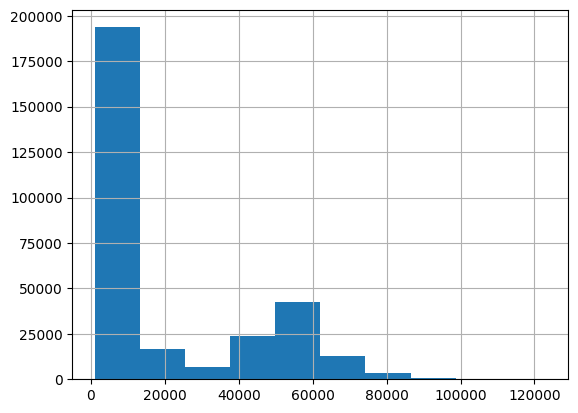

In [11]:
#Affichage Histogramme de la variable cible :
df['price'].hist()

Nous déduisons que la majorité des billets d'avion ont un prix <20000

La distribution ne suit pas la loi normale

Nos données contiennent des outliers(cf. Graphe ci-dessous)

{'whiskers': [<matplotlib.lines.Line2D at 0x1a03245f950>,
 'caps': [<matplotlib.lines.Line2D at 0x1a03246cfd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1a0322623d0>],
 'medians': [<matplotlib.lines.Line2D at 0x1a03246e810>],
 'fliers': [<matplotlib.lines.Line2D at 0x1a03246f310>],
 'means': []}

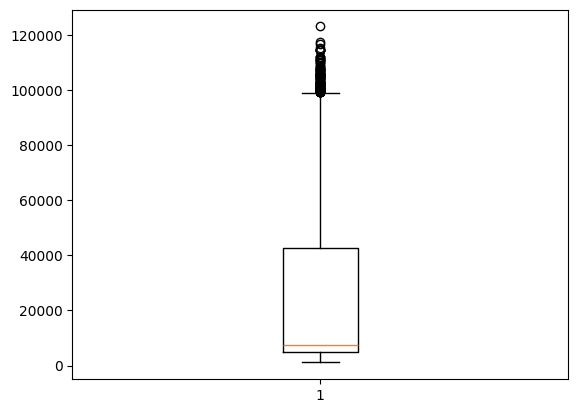

In [12]:
plt.boxplot(df['price'])

In [13]:
df["airline"].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

certaines compagnies apparaissent beaucoup plus fréquemment que d’autres dans le dataset

In [14]:
df.groupby("airline")["price"].mean()

airline
AirAsia       4091.072742
Air_India    23507.019112
GO_FIRST      5652.007595
Indigo        5324.216303
SpiceJet      6179.278881
Vistara      30396.536302
Name: price, dtype: float64

le prix moyen des billets varie selon la compagnie aérienne.

In [15]:
df.groupby("stops")["price"].mean()

stops
one            22900.992482
two_or_more    14113.450775
zero            9375.938535
Name: price, dtype: float64

le prix moyen des vols sans escale est relativement plus élevé que ceux avec des escales

In [16]:
df.groupby("class")["price"].mean()

class
Business    52540.081124
Economy      6572.342383
Name: price, dtype: float64

La class du vol impacte significativement les prix des vol

<Axes: >

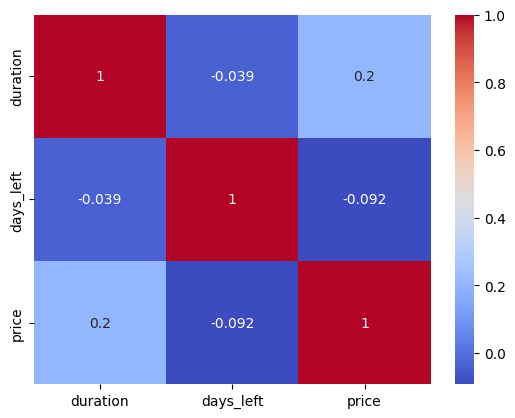

In [17]:
#Correlation entre les variables numériques :
sns.heatmap(df[["duration", "days_left", "price"]].corr(), annot=True, cmap='coolwarm')

duration présente une corrélation positive avec le prix

days_left montre généralement une corrélation négative avec le prix

#### Conclusion EDA

L’étude exploratoire des données a permis d’identifier les principales caractéristiques du dataset et de mieux comprendre les éléments ayant une influence sur le prix des billets d’avion.

Les analyses réalisées montrent que certaines variables, comme la compagnie aérienne, la classe du voyage ou encore le nombre d’escales, jouent un rôle important dans la variation des prix. Par ailleurs, la distribution des données présente une forte asymétrie ainsi que plusieurs valeurs extrêmes, ce qui oriente le choix vers des modèles capables de bien gérer ce type de données.

En se basant sur les différents cette analyse, ne remarquons également une forte relation entre le prix des vol et les variables catégorielles, donc nous aurons à appliquer une méthode d'encodage lors de la prochaine étape.

### 3-Pré-processing des données

Nous avons déjà supprimé la première colonne qui ne contenait pas d'information relative à notre sujet.

D'un point de vue métier, le numero de vol n'a aucun effet sur notre variable cible, donc c'est une colonne a supprimer sur la prochaine étape.


In [18]:
df=df.drop('flight', axis=1)

On split notre dataset en données d'entraînement et de test :

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = np.log(df['price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

Selon l'analyse exploratroire sur l'étape précédent, nous avons déduis que les variables catégorielle ont un effet sur notre variable target, de ce fait, nous passons à l'encodage : 

Label Encoding : 
* stops
* class

One-Hot Encoding : 
* airline
* source_city
* departure_time
* arrival_time


In [ ]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

le_stops = LabelEncoder()
X_train['stops'] = le_stops.fit_transform(X_train['stops'])
X_test['stops'] = le_stops.transform(X_test['stops'])

le_class = LabelEncoder()
X_train['class'] = le_class.fit_transform(X_train['class'])
X_test['class'] = le_class.transform(X_test['class'])

cat_features = ['airline', 'departure_time', 'arrival_time', 
                'source_city', 'destination_city']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

Normalisation des valeurs

In [21]:
scaler = StandardScaler(with_mean=False)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
from sklearn.preprocessing import LabelEncoder

le_stops = LabelEncoder()
df['stops'] = le_stops.fit_transform(df['stops'])

le_class = LabelEncoder()
df['class'] = le_class.fit_transform(df['class'])
df = pd.get_dummies(df, columns=['airline', 'departure_time', 'arrival_time'], drop_first=True)


In [23]:
df.head()

,source_city,stops,destination_city,class,duration,days_left,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,...,departure_time_Early_Morning,departure_time_Evening,departure_time_Late_Night,departure_time_Morning,departure_time_Night,arrival_time_Early_Morning,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night
0,Delhi,2,Mumbai,1,2.17,1,5953,False,False,False,...,False,True,False,False,False,False,False,False,False,True
1,Delhi,2,Mumbai,1,2.33,1,5953,False,False,False,...,True,False,False,False,False,False,False,False,True,False
2,Delhi,2,Mumbai,1,2.17,1,5956,False,False,False,...,True,False,False,False,False,True,False,False,False,False
3,Delhi,2,Mumbai,1,2.25,1,5955,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,Delhi,2,Mumbai,1,2.33,1,5955,False,False,False,...,False,False,False,True,False,False,False,False,True,False


Import des algorithmes 

In [24]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.svm import LinearSVR

Listing des algorithmes que nous allons tester pour en choisir les 3 performants

In [25]:
models ={
        'Linear Regression': LinearRegression(),
         'Ridge': Ridge(),
         'Lasso': Lasso(),
         'ENet': ElasticNet(),
         'DT': DecisionTreeRegressor(random_state=42),
         'LSVR':LinearSVR(),
         "Gradient Boosting": GradientBoostingRegressor(),
        "AdaBoost": AdaBoostRegressor(),
        "XGBoost": XGBRegressor(random_state=42),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42,max_depth=15,n_jobs=-1)    

}

des tests de fit on été réalisés sans définir de n_estimator ni max_depth pour le modèle random forest, sauf que le temps de traitement dépassait une heure sur des cas, donc les paramètres ont été définies.

Création d'une fonction permettant de démarrer l'entrainement , et retourner les résultats MAE , RMSE , R2 et le temps de traitement

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []
import time
def evaluate_model(name, model):
    start = time.time()
    model.fit(X_train, y_train)
   
    y_train_pred = np.expm1(model.predict(X_train))
    y_pred = np.expm1(model.predict(X_test))
    
    mae = round(mean_absolute_error(np.expm1(y_test), y_pred), 2)
    rmse = round(np.sqrt(mean_squared_error(np.expm1(y_test), y_pred)), 2)
    r2 = round(r2_score(np.expm1(y_test), y_pred), 2)
    duration = round(time.time() - start, 2)
    results.append([name, mae, rmse, r2, duration])
    return {
        "name": name,
        "model": model,
        "y_train_pred": y_train_pred,
        "y_test_pred": y_pred
    }

Entrainement en boucles sur tous les modèles de notre liste définie un peu plus haut et stocker les résultats dans une liste

In [27]:
models_outputs=[]
for name, model in models.items():
    
    output =evaluate_model(name, model)
    
    models_outputs.append(output)

Convertir la liste en dataframe

In [28]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2","duration"])
results_df = results_df.sort_values(by="R2", ascending=False).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2,duration
0,Random Forest,1760.46,3414.34,0.98,385.47
1,DT,1158.26,3492.31,0.98,56.56
2,XGBoost,2093.53,3821.94,0.97,2.78
3,Gradient Boosting,2971.89,5119.86,0.95,37.59
4,AdaBoost,3589.14,5896.95,0.93,19.50
5,LSVR,4577.65,7686.60,0.89,69.48
6,Ridge,4778.51,8143.81,0.87,0.24
7,Linear Regression,4778.48,8143.73,0.87,0.30
8,ENet,13316.82,20713.85,0.18,0.19
9,Lasso,16614.70,24704.57,-0.17,0.21


On affiche les résultats sous format de graphe pour simplifier l'interpretation des résultats

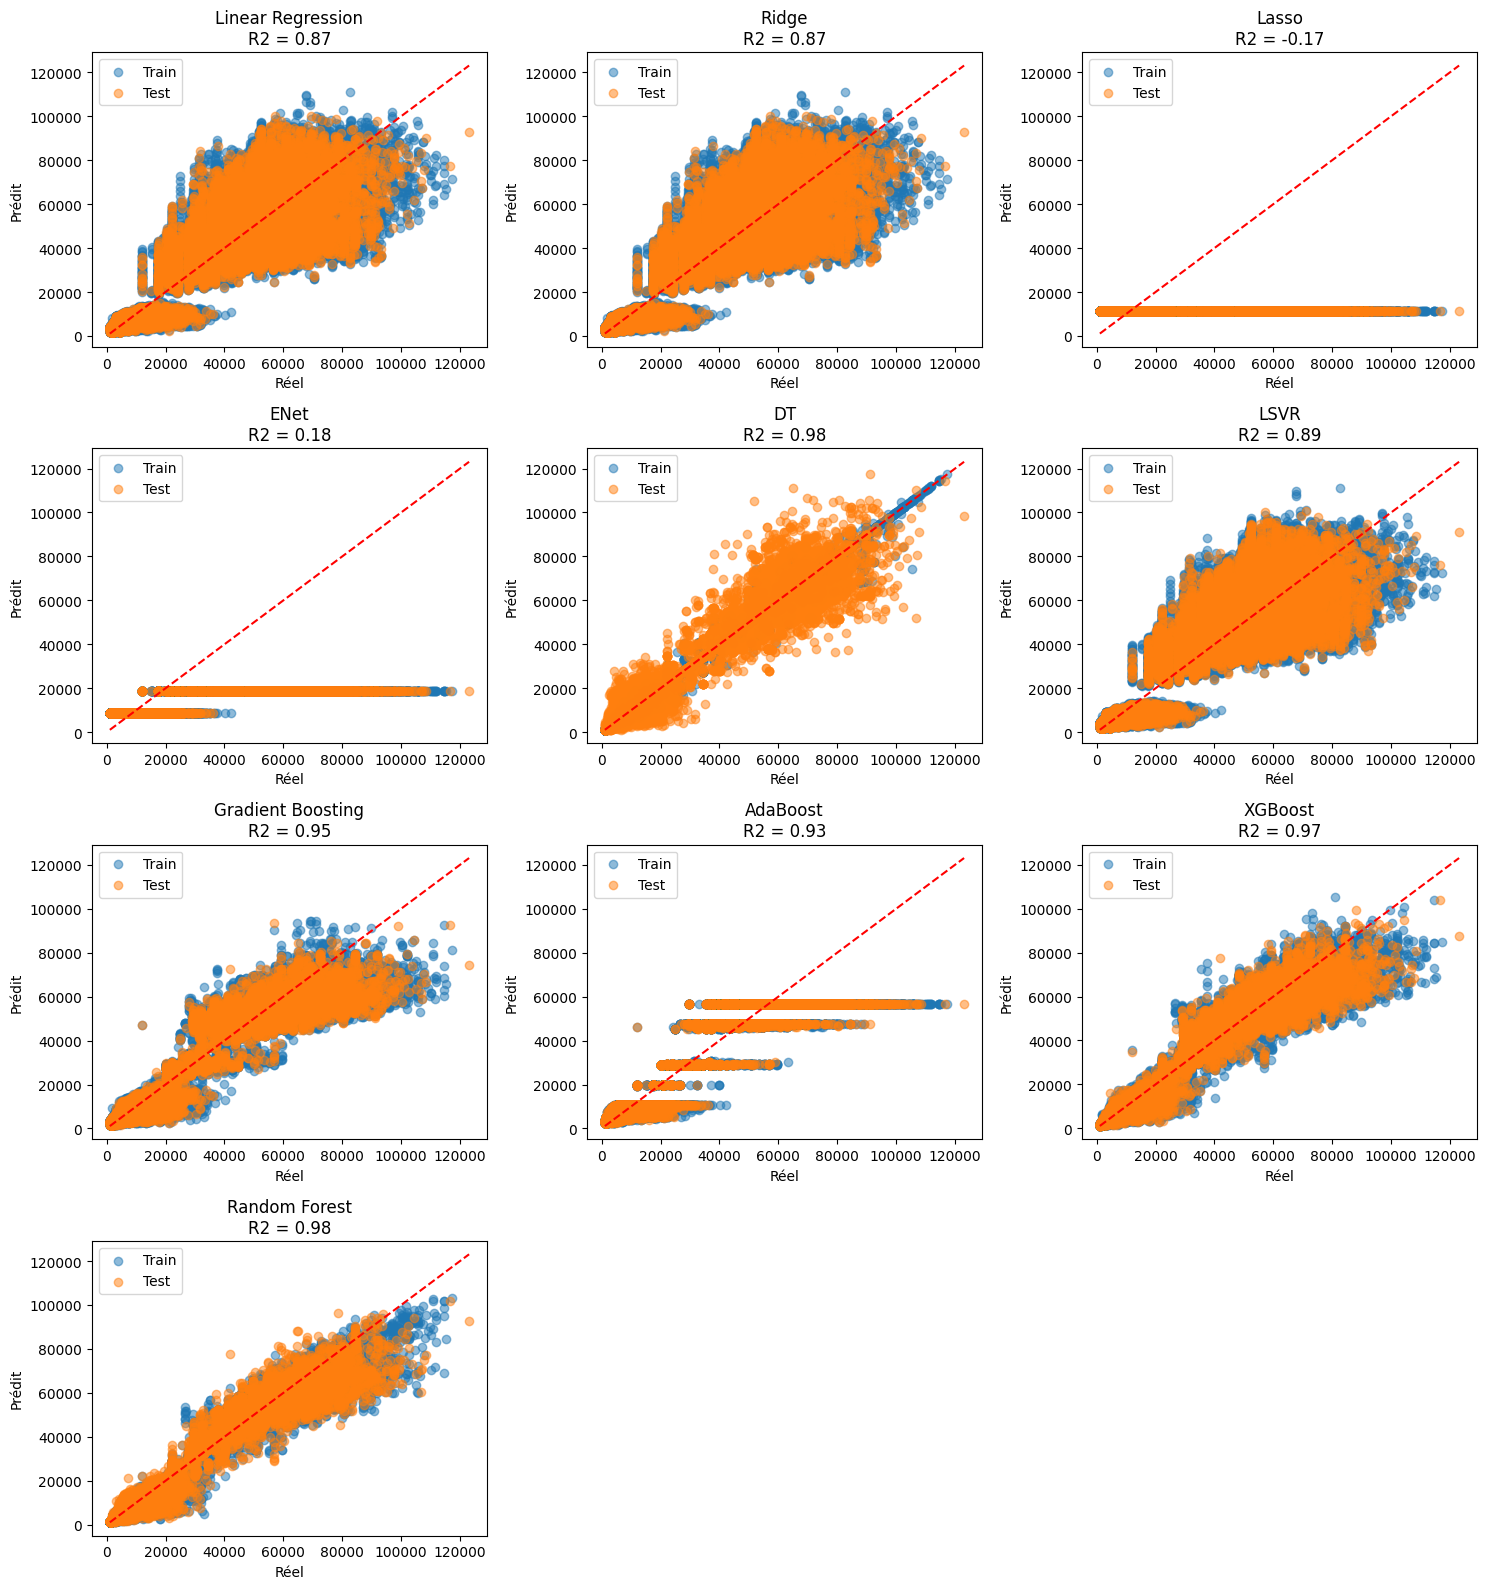

In [29]:
import math

n = len(models_outputs)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()


y_train_real = np.expm1(y_train)
y_test_real  = np.expm1(y_test)

for i, output in enumerate(models_outputs):

    name         = output["name"]
    y_train_pred = output["y_train_pred"]   
    y_test_pred  = output["y_test_pred"]    

    ax = axes[i]
    ax.scatter(y_train_real, y_train_pred, alpha=0.5, label="Train")
    ax.scatter(y_test_real,  y_test_pred,  alpha=0.5, label="Test")

    min_val = min(y_train_real.min(), y_test_real.min())
    max_val = max(y_train_real.max(), y_test_real.max())

    ax.plot([min_val, max_val], [min_val, max_val], "r--")

    r2 = r2_score(y_test_real, y_test_pred)
    ax.set_title(f"{name}\nR2 = {r2:.2f}")
    ax.set_xlabel("Réel")
    ax.set_ylabel("Prédit")
    ax.legend()

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

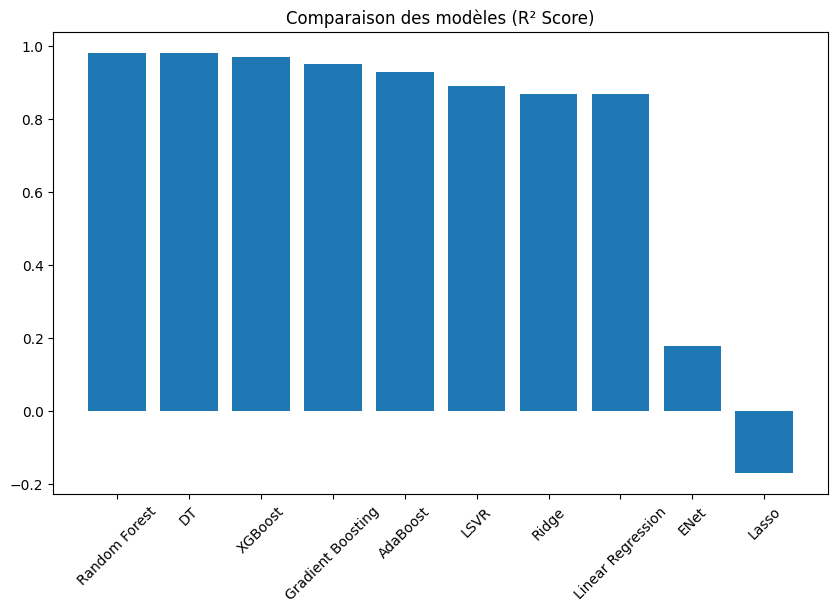

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(results_df["Model"], results_df["R2"])
plt.xticks(rotation=45)
plt.title("Comparaison des modèles (R² Score)")
plt.show()

Cross validation des modèles ayant les top 3 R2

selon le plot, DT risque d'être en overfitting

In [31]:
models =[("Gradient Boosting", GradientBoostingRegressor()),
          ("XGBoost", XGBRegressor(random_state=42)),
          ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15, n_jobs=-1))]

Via une cross validation, on test si l'un des 3 modèles est instable

In [32]:
from sklearn.model_selection import cross_val_score, KFold


#étant donné que nous n'avions pas appliqué un encodage sur une copie du dataset avant split, on l'applique actuellement pour la cross validation
df_cv = df.copy()
le = LabelEncoder()
df_cv['source_city'] = le.fit_transform(df_cv['source_city'])
df_cv['destination_city'] = le.fit_transform(df_cv['destination_city'])

X_cv = df_cv.drop('price', axis=1)
y_cv = df_cv['price']

scoring = 'r2'
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

names = []
cv_res = []
cv_res_mean = []
cv_res_std = []

for name, model in models:
    res = cross_val_score(model, X_cv, y_cv, scoring=scoring, cv=kfold, n_jobs=-1)
    names.append(name)
    cv_res.append(res)
    cv_res_mean.append(round(np.mean(res), 3))
    cv_res_std.append(round(np.std(res), 3))


In [33]:
cv_df = pd.DataFrame({
    'Model': names,
    'R2_CV': cv_res_mean,
    'R2_CV_std': cv_res_std
})

results_df = results_df.merge(cv_df, on='Model')
results_df

,Model,MAE,RMSE,R2,duration,R2_CV,R2_CV_std
0,Random Forest,1760.46,3414.34,0.98,385.47,0.979,0.000
1,XGBoost,2093.53,3821.94,0.97,2.78,0.976,0.000
2,Gradient Boosting,2971.89,5119.86,0.95,37.59,0.952,0.001


Tuning des 3 modèles

In [34]:
from sklearn.model_selection import RandomizedSearchCV

#XGBoost 
param_xgb = {
    'n_estimators'    : [100, 300, 500],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

rs_xgb = RandomizedSearchCV(
    XGBRegressor(tree_method='hist', random_state=42),
    param_xgb,
    n_iter=20, cv=5, scoring='r2',
    n_jobs=-1, random_state=42, verbose=1
)
rs_xgb.fit(X_train, y_train)
print("XGBoost meilleurs params :", rs_xgb.best_params_)
print("XGBoost meilleur R²      :", round(rs_xgb.best_score_, 3))

#Random Forest
param_rf = {
    'n_estimators'   : [100, 200],
    'max_depth'      : [10, 15, 20],
    'min_samples_leaf': [5, 10, 20],
    'max_features'   : ['sqrt', 0.5],
    'bootstrap'      : [True, False]
}

rs_rf = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42),
    param_rf,
    n_iter=10, cv=3, scoring='r2',
    n_jobs=-1, random_state=42, verbose=1
)
rs_rf.fit(X_train, y_train)
print("RF meilleurs params :", rs_rf.best_params_)
print("RF meilleur R²      :", round(rs_rf.best_score_, 3))

#Gradient Boosting
param_gb = {
    'n_estimators'   : [100, 200, 300],
    'max_depth'      : [3, 4, 5],
    'learning_rate'  : [0.05, 0.1, 0.2],
    'subsample'      : [0.7, 0.8, 1.0],
    'min_samples_leaf': [5, 10, 20]
}

rs_gb = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_gb,
    n_iter=15, cv=3, scoring='r2',
    n_jobs=-1, random_state=42, verbose=1
)
rs_gb.fit(X_train, y_train)
print("GB meilleurs params :", rs_gb.best_params_)
print("GB meilleur R²      :", round(rs_gb.best_score_, 3))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
XGBoost meilleurs params : {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
XGBoost meilleur R²      : 0.983
Fitting 3 folds for each of 10 candidates, totalling 30 fits
RF meilleurs params : {'n_estimators': 100, 'min_samples_leaf': 20, 'max_features': 0.5, 'max_depth': 20, 'bootstrap': True}
RF meilleur R²      : 0.974
Fitting 3 folds for each of 15 candidates, totalling 45 fits
GB meilleurs params : {'subsample': 0.8, 'n_estimators': 300, 'min_samples_leaf': 10, 'max_depth': 5, 'learning_rate': 0.2}
GB meilleur R²      : 0.973


XGBoost : progression significative après tuning sur le R2 & MAE 

Random forest : pas de différence après tuning vs le modèle initial 

Gradient Boosting : la plus grande progression après tuning , sauf qu'il reste en dessous du XGBoost



In [35]:
best_models = {
    'XGBoost'          : rs_xgb.best_estimator_,
    'Random Forest'    : rs_rf.best_estimator_,
    'Gradient Boosting': rs_gb.best_estimator_
}

rows = []
for name, model in best_models.items():
    # ── Retransformer en prix réels ───────────────────────
    y_pred      = np.expm1(model.predict(X_test))
    y_test_real = np.expm1(y_test)

    rows.append({
        'Model': name,
        'MAE'  : round(mean_absolute_error(y_test_real, y_pred), 2),
        'RMSE' : round(np.sqrt(mean_squared_error(y_test_real, y_pred)), 2),
        'R2'   : round(r2_score(y_test_real, y_pred), 3)
    })

results_after = pd.DataFrame(rows).sort_values('R2', ascending=False)

results_after_renamed = results_after.rename(columns={
    'MAE' : 'MAE_apres',
    'RMSE': 'RMSE_apres',
    'R2'  : 'R2_apres'
})

results_df_renamed = results_df.rename(columns={
    'MAE' : 'MAE_avant',
    'RMSE': 'RMSE_avant',
    'R2'  : 'R2_avant'
})

compare = results_df_renamed.merge(results_after_renamed, on='Model')

compare['Delta_MAE']  = round(compare['MAE_avant']  - compare['MAE_apres'],  2)
compare['Delta_RMSE'] = round(compare['RMSE_avant'] - compare['RMSE_apres'], 2)
compare['Delta_R2']   = round(compare['R2_apres']   - compare['R2_avant'],   3)

cols = ['Model','MAE_avant','MAE_apres','Delta_MAE','RMSE_avant','RMSE_apres','Delta_RMSE','R2_avant','R2_apres','Delta_R2']
print(compare[cols].to_string(index=False))

            Model  MAE_avant  MAE_apres  Delta_MAE  RMSE_avant  RMSE_apres  Delta_RMSE  R2_avant  R2_apres  Delta_R2
    Random Forest    1760.46    1676.74      83.72     3414.34     3254.00      160.34      0.98     0.980     0.000
          XGBoost    2093.53    1481.05     612.48     3821.94     2867.23      954.71      0.97     0.984     0.014
Gradient Boosting    2971.89    2143.09     828.80     5119.86     3887.13     1232.73      0.95     0.971     0.021


In [ ]:
# modèle final : XGBoost tuné
final_model = rs_xgb.best_estimator_

#Retransformer en prix réels
y_train_real = np.expm1(y_train)
y_test_real  = np.expm1(y_test)
y_pred_train = np.expm1(final_model.predict(X_train))
y_pred_test  = np.expm1(final_model.predict(X_test))

metrics = pd.DataFrame({
    'Set'  : ['Train', 'Test'],
    'MAE'  : [round(mean_absolute_error(y_train_real, y_pred_train), 2),
              round(mean_absolute_error(y_test_real,  y_pred_test),  2)],
    'RMSE' : [round(np.sqrt(mean_squared_error(y_train_real, y_pred_train)), 2),
              round(np.sqrt(mean_squared_error(y_test_real,  y_pred_test)),  2)],
    'R2'   : [round(r2_score(y_train_real, y_pred_train), 3),
              round(r2_score(y_test_real,  y_pred_test),  3)]
})

print(metrics.to_string(index=False))
print(f"\nDelta_R2  (Train - Test) : {metrics['R2'][0]  - metrics['R2'][1]:.3f}")
print(f"Delta_MAE (Train - Test) : {metrics['MAE'][0] - metrics['MAE'][1]:.2f}")

  Set     MAE    RMSE    R2
Train 1351.86 2643.56 0.986
 Test 1481.05 2867.23 0.984

Delta_R2  (Train - Test) : 0.002
Delta_MAE (Train - Test) : -129.19


le delta R2 est quasi null , delta MAE à -129 ce qui signifie pas d'overfitting



In [43]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
import joblib

df=pd.read_csv('Clean_Dataset.csv')
df=df.drop(['Unnamed: 0','flight'], axis=1)
# repartir de X et y bruts
X_raw = df.drop('price', axis=1)
y_raw = np.log1p(df['price'])

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=40
)

#Preprocessing intégré
ordinal_cols = ['stops', 'class']
ohe_cols     = ['airline', 'departure_time', 'arrival_time',
                'source_city', 'destination_city']

preprocessor_full = ColumnTransformer([
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value',
                               unknown_value=-1), ordinal_cols),
    ('ohe',     OneHotEncoder(handle_unknown='ignore'),  ohe_cols),
], remainder='passthrough')

#Pipeline final
final_pipeline = Pipeline([
    ('preprocessor', preprocessor_full),
    ('scaler',       StandardScaler(with_mean=False)),
    ('model',        XGBRegressor(
                        subsample        = 1.0,
                        n_estimators     = 500,
                        max_depth        = 8,
                        learning_rate    = 0.1,
                        colsample_bytree = 0.8,
                        tree_method      = 'hist',
                        random_state     = 42
                    ))
])

#entraînement
final_pipeline.fit(X_train_raw, y_train_raw)

#Métriques en prix réels
y_pred      = np.expm1(final_pipeline.predict(X_test_raw))
y_test_real = np.expm1(y_test_raw)

print("R²   :", round(r2_score(y_test_real, y_pred), 3))
print("MAE  :", round(mean_absolute_error(y_test_real, y_pred), 2))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test_real, y_pred)), 2))

#Sauvegarde
joblib.dump(final_pipeline, r'C:\Users\Reda\Desktop\Projet_ML_Reda_EL_BAHAOUI\Billet_avion_pipeline.pkl')



R²   : 0.984
MAE  : 1490.15
RMSE : 2889.73


['C:\\Users\\Reda\\Desktop\\Projet_ML_Reda_EL_BAHAOUI\\Billet_avion_pipeline.pkl']